In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### 1. Load dataset

In [2]:
data = pd.read_csv("./../data/all_bundestag_speeches_preprocessed.csv",sep=";")

/tmp/ipykernel_6568/518715225.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("./../data/all_bundestag_speeches_preprocessed.csv",sep=";")


In [3]:
len(data)

260660

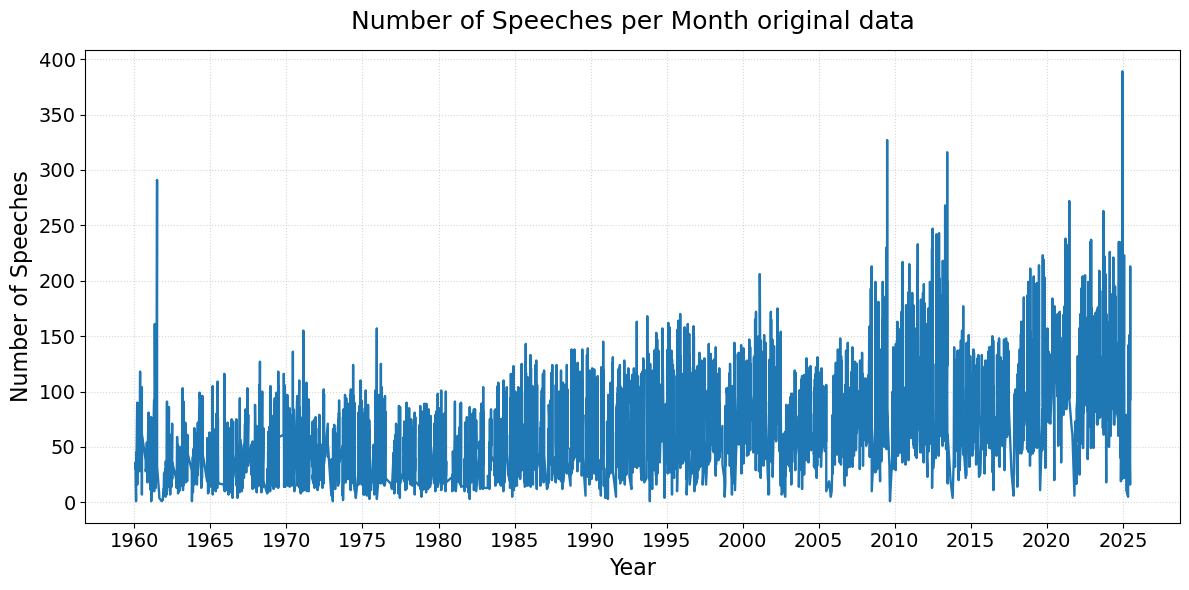

In [25]:
monthly_counts = data.groupby("date").size().reset_index(name="count")
monthly_counts = monthly_counts.sort_values("date")

# Ensure 'date' is a datetime type
monthly_counts["date"] = pd.to_datetime(monthly_counts["date"])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_counts["date"], monthly_counts["count"], color="#1f77b4", linewidth=1.7)

# Set ticks every 5 years
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Number of Speeches per Month original data", fontsize=18, pad=15)
plt.xlabel("Year", fontsize=16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Number of Speeches", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### Multi-Keyword Rule-Based Filtering for Immigration Speeches

In [ ]:
import re

migration_keywords = [
    r"migration",
    r"zuwander",      # Zuwanderung, Zuwanderer, ...
    r"einwander",     # Einwanderung, ...
    r"asyl",
    r"fluechtling",
    r"gefluechtet",
    r"schutzsuchend",
    r"fachkraefte",
    r"pflege",
    r"auslaend",
    r"vertrieben",
    r"migrant",
    r"aussiedler",
    r"ansiedler",
    r"buergerkriegs",

]

# Count how many different keyword groups are present
def count_keyword_matches(text):
    if pd.isna(text):
        return 0

    text = text.lower()

    count = 0
    for keyword in migration_keywords:
        if re.search(rf"\b{keyword}", text):
            count += 1

    return count

# Number of matched keyword groups
data["migration_keyword_count"] = (
    data["text_preprocessed_lemmatized"]
    .apply(count_keyword_matches)
)

# Select speeches with at least two keyword groups
data["is_immigration"] = data["migration_keyword_count"] >= 3

df_immigration = data[data["is_immigration"]].copy()

print(f"Total speeches: {len(data):,}")
print(f"Immigration speeches: {len(df_immigration):,} ({len(df_immigration)/len(data):.1%})")

Total speeches: 260,660
Immigration speeches: 4,361 (1.7%)


In [6]:
import re

migration_keywords = [
    r"migration",
    r"zuwander",      # Zuwanderung, Zuwanderer, ...
    r"einwander",     # Einwanderung, ...
    r"asyl",
    r"fluechtling",
    r"gefluechtet",
    r"schutzsuchend",
    r"auslaend",
    r"vertrieben",
    r"migrant",
    r"aussiedler",
    r"ansiedler",
    r"buergerkriegs",

]

# Count how many different keyword groups are present
def count_keyword_matches(text):
    if pd.isna(text):
        return 0

    text = text.lower()

    count = 0
    for keyword in migration_keywords:
        if re.search(rf"\b{keyword}", text):
            count += 1

    return count

# Number of matched keyword groups
data["migration_keyword_count"] = (
    data["text_preprocessed_lemmatized"]
    .apply(count_keyword_matches)
)

# Select speeches with at least two keyword groups
data["is_immigration"] = data["migration_keyword_count"] >= 1

df_immigration = data[data["is_immigration"]].copy()

print(f"Total speeches: {len(data):,}")
print(f"Immigration speeches: {len(df_immigration):,} ({len(df_immigration)/len(data):.1%})")

Total speeches: 260,660
Immigration speeches: 28,662 (11.0%)


In [7]:
df_immigration.to_csv("./results/immigration_speeches_short.csv")

In [2]:
df = pd.read_csv("./results/immigration_speeches_short.csv")

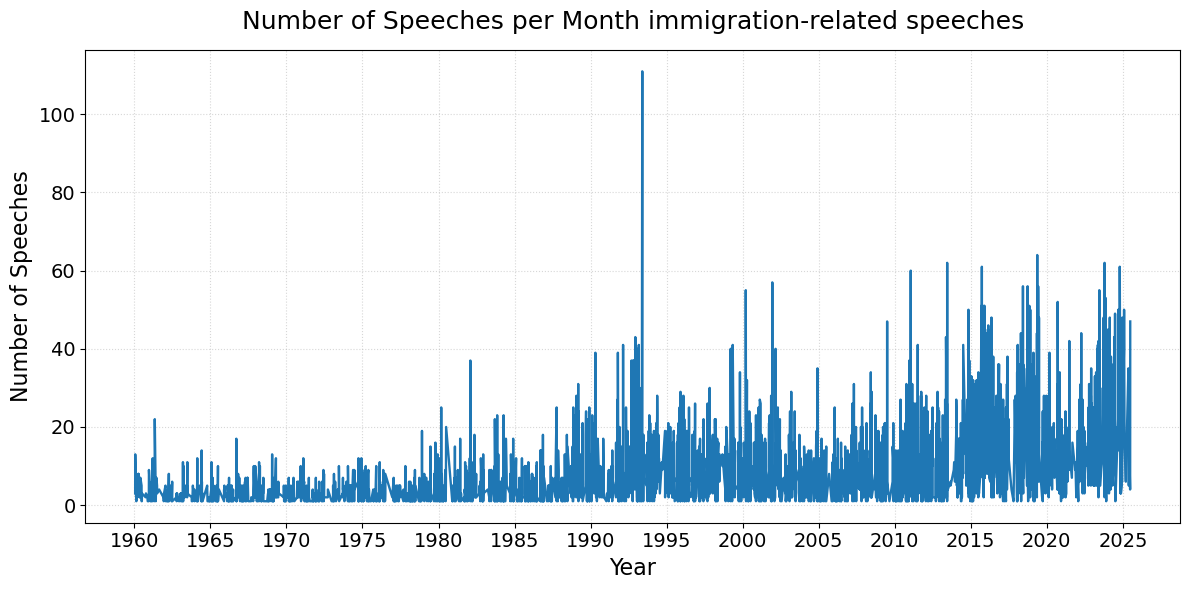

In [26]:
monthly_counts = df_immigration.groupby("date").size().reset_index(name="count")
monthly_counts = monthly_counts.sort_values("date")

# Ensure 'date' is a datetime type
monthly_counts["date"] = pd.to_datetime(monthly_counts["date"])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_counts["date"], monthly_counts["count"], color="#1f77b4", linewidth=1.7)

# Set ticks every 5 years
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Number of Speeches per Month immigration-related speeches", fontsize=18, pad=15)
plt.xlabel("Year", fontsize=16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Number of Speeches", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
monthly_counts["count"].describe()

count    3311.000000
mean        8.656599
std         9.621391
min         1.000000
25%         2.000000
50%         5.000000
75%        12.000000
max       111.000000
Name: count, dtype: float64

### Close reading of immigration speeches

In [5]:
df_immigration["Party"].unique()

array(['CDU/CSU', 'Cabinet', 'FDP', 'DP', 'SPD', 'fraktionslos', 'GRÜNE',
       'PDS', 'LINKE', 'AfD', 'SPDCDU/CSU', 'BSW'], dtype=object)

In [6]:
gruene = df_immigration[ (df_immigration["Party"]=="GRÜNE") ]
len(gruene)

714

In [5]:
cducsu = df_immigration[ (df_immigration["Party"]=="CDU/CSU") ]
len(cducsu)

1364

In [32]:
linke = df_immigration[ (df_immigration["Party"]=="LINKE") ]
len(linke)

5313

In [33]:
FDP = df_immigration[ (df_immigration["Party"]=="FDP") ]
len(FDP)

10444

In [137]:
SPDCDUCSU = df_immigration[ (df_immigration["Party"]=="SPDCDU/CSU") ]
len(SPDCDUCSU)

1

In [138]:
BSW = df_immigration[ (df_immigration["Party"]=="BSW") ]
len(BSW)

13

In [139]:
Cabinet = df_immigration[ (df_immigration["Party"]=="Cabinet") ]
len(Cabinet)

1982

In [7]:
gruene["text"].to_list()[713]

'Sehr geehrter Herr Präsident! Meine Damen und Herren! Eine der ersten Amtshandlungen dieser Bundesregierung ist es, hochqualifizierten, gut integrierten Menschen den Zugang zur deutschen Staatsbürgerschaft wieder zu erschweren – in einer Zeit, in der dieses Land Fachkräfte händeringend sucht: vom Krankenhaus bis zur Kita, Herr Dobrindt, vom Handwerksbetrieb bis zum Hightechlabor. Das ist nicht nur unfair, das ist unvernünftig, liebe Kolleginnen und Kollegen. Und vor allem ist es eines: das genaue Gegenteil von dem, was wir eigentlich bräuchten.\n\nDie Zahlen belegen es schwarz auf weiß: Die Reform des Staatsangehörigkeitsrechts, lieber Hakan, aus der letzten Legislatur hat gewirkt. Mehr Menschen wollen deutsche Staatsangehörige werden, weil sie sich zu diesem Land bekennen. Und auch mir geht es so, dass ich ständig darauf angesprochen werde: ob in der Bahn vom Zugpersonal, von unseren Pförtnerinnen und Pförtnern hier im Bundestag oder erst vor Kurzem im Krankenhaus von einer Pflegekra

'Sehr geehrter Herr Präsident! Meine Damen und Herren! Eine der ersten Amtshandlungen dieser Bundesregierung ist es, hochqualifizierten, gut integrierten Menschen den Zugang zur deutschen Staatsbürgerschaft wieder zu erschweren – in einer Zeit, in der dieses Land Fachkräfte händeringend sucht: vom Krankenhaus bis zur Kita, Herr Dobrindt, vom Handwerksbetrieb bis zum Hightechlabor. Das ist nicht nur unfair, das ist unvernünftig, liebe Kolleginnen und Kollegen. Und vor allem ist es eines: das genaue Gegenteil von dem, was wir eigentlich bräuchten.\n\nDie Zahlen belegen es schwarz auf weiß: Die Reform des Staatsangehörigkeitsrechts, lieber Hakan, aus der letzten Legislatur hat gewirkt. Mehr Menschen wollen deutsche Staatsangehörige werden, weil sie sich zu diesem Land bekennen. Und auch mir geht es so, dass ich ständig darauf angesprochen werde: ob in der Bahn vom Zugpersonal, von unseren Pförtnerinnen und Pförtnern hier im Bundestag oder erst vor Kurzem im Krankenhaus von einer Pflegekraft. Alle sagen mir sinngemäß das Gleiche: Endlich, endlich erkennt Deutschland an, dass wir dazugehören, dass wir Teil dieses Landes sind. – Das ist ein demokratischer Fortschritt, Herr Innenminister, ein Grund zur Freude und eigentlich ein Grund zum Feiern. Ich hoffe, Sie können ein bisschen feiern.\n\nUnd was macht die Regierung? Sie dreht die Uhr zurück. Sie zieht die Hand zurück, die wir gerade ausgestreckt haben. Das ist aus unserer Sicht ein fatales Signal an all jene, die sich für ein Leben in Deutschland entschieden haben.\n\nMeine Damen und Herren, mit jeder Einbürgerung holen wir im Übrigen ein demokratisches Defizit auf, das das Bundesverfassungsgericht angemahnt hat. Wir schließen die Lücke zwischen denen, die hier leben, und denen, die politisch mitentscheiden dürfen. Die Studienlage ist eindeutig. Wer eingebürgert ist, hat besseren Zugang zum Arbeitsmarkt, verdient im Übrigen mehr, ist politisch aktiver und sozial integrierter. Einbürgerung, liebe Kolleginnen und Kollegen, ist kein Geschenk; sie ist ein Investment in dieses Land, in unsere Zukunft.\n\nDeshalb fragen wir Sie: Warum, um Himmels willen, wollen Sie ausgerechnet dieses Instrument wieder abschaffen? Was CDU/CSU und SPD hier planen, ist wirklich eine rückwärtsgewandte Symbolpolitik auf Kosten derer, die sich tagtäglich für dieses Land einsetzen: ob als Ärztin oder Arzt, Jens Spahn, Busfahrer/-in, Pflegekraft oder Informatiker/-in.\n\nAuch die SPD trägt diese Kehrtwende mit. Ein fatales Signal aus unserer Sicht. Ein fatales Signal gerade an diejenigen, die sich bewusst für Deutschland entschieden haben und alle Voraussetzungen einfach frühzeitiger erfüllen. Das sind dieselben Voraussetzungen, zugleich noch durch weitere Voraussetzungen erschwert; und die erfüllen sie frühzeitiger.\n\nDeutschland ist längst ein Einwanderungsland. Deshalb können wir nur sagen: Statt auf Zukunft zu setzen, klammern Sie sich an ein Deutschland, das es schon längst nicht mehr gibt. Statt Chancen zu schaffen, schaffen Sie Hürden. Statt Mut zu machen, machen Sie wieder Angst. Damit wird Vertrauen zerstört, das Vertrauen derer, die sich mit vollem Herzen für Deutschland entschieden haben.\n\nLiebe Kolleginnen und Kollegen, Bündnis 90/Die Grünen stehen für das moderne Staatsangehörigkeitsrecht, das wir geschaffen haben, eines, das Menschen willkommen heißt und ihnen nicht misstraut.\n\nWir empfehlen, diesen Gesetzentwurf zurückzuziehen.\n\nHerzlichen Dank.'


In [9]:
gruene["text_preprocessed_lemmatized"].to_list()[706]

'lieben merz uebernehmen amt schwierig angriffskrieg russlands ukraine unvermindert brutalitaet fortsetzen amerikanische schreddert usa verlassen abgeordnete rechtsextrem deutsche sitzen merz ankommen ankommen differenz trennen name gruen bundestagsfraktion naechst wuensche verdienen verdienen merz denkbar schwierig start deutsche miersch merz kleinigkeit kanzler wahlgang einmalig abgeordnete deutsche kanzlerwahl zentrale vertrauensabstimmung zentrale frage spitze abgeordnete geht vertraut zentral frage bitter nachricht vertrauen instabil merz darauffolgend kanzlerschaft ruhe stabilitaet ausrechnen europapolitik schwerpunkt kanzler chaos merz europaeisch regierungschefs erstes ukraine gefahren signal paris warschau gefahren bundeskanzleramt auswaertige amt irgendwoher diplomatische idee polnisch regierungschef ausrechnen antrittsbesuch quasi vergiftet gastgeschenk verschaerfen schliessung grenze pol zurueckweisung gefluechtete pol mitbringen signal polnische wundern donald tusk maximal

'zukuenftig mangel technisch fachleute unbestritten gegensteu ern fehlentwicklungen schwarz gelb korrigieren analysieren werfen mangel inge nieuren mangel it fachkraeften fehl entwicklungen ursache straefliche vernachlaessigung bildung forschung ausmachen ausgabe schrittweise insge samt million zusammengestrichen ha ben uebernahme regierungsverantwortung etat bildung forschung milliarde erhoehen ver messen behaupten geld strukturell veraenderung nachwuchs na turwissenschaften heranzufuehren sofern kompe tenzverteilung zulaesst rasch verbreitung informa tions kommunikationstechnologien weiterbildung inhaltliche strukturell herausforderung bildungs einrichtungen multimediafaehigen computer ternetanschluessen ausstatten didaktisch hochwer tige bildungssoftware bereitstellen bereitstellung reichend qualifizieren it fachkraefteangebotes multimediagestuetzte lehren lernen entwickeln beseitigung mangel qualifizieren fachkraeften informations kommunikati onstechnik fach themendialog beschaef tigungspotenziale informationswirtschaft rah men ausbildung wettbewerbsfaehigkeit massnahmenpaket steigerung it ausbildungsstellen weitung it weiterbil dungsangebotes ergaenzen greencard initiative dame anscheinen stehend entnehmen moegen antrages bemerkenswert frage anzahl auslaendisch studierender hochschu len niedrige anzahl be rot gruene jeher anwerben auslaendisch studierende wissenschaftler wissenschafts hochschulstandort verstaerken zuwanderungsgesetzes ueberflues sige behoerdengaenge aufheben aufenthaltserlaub nis studium verlaengern zukunftsorientierte vorausset zungen ebene fuehrungspositionen ver unterschiedlich sichtweisen denk ansaetze fortschritt bildung forschung punktaufgabe bmbf bmbf referat bildung forschung deutscher etablieren gender mainstreaming bmbf durchsetzen mithilfe haushaltsti tels strategie durchsetzung chancengleichheit bildung forschung antrages frueh sodass befuerchten ingenieurmangel'


#### extracting pro-immigration speeches 

In [19]:
positive_speech = gruene.iloc[[713]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

In [ ]:
# Initialize or append to a new dataframe
row_to_add = gruene.iloc[[293]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If positive_speech already exists as a DataFrame:
positive_speech = pd.concat([positive_speech, row_to_add], ignore_index=True)

In [ ]:
gruene.iloc[703]

speech_identification_ent                                           Emilia Fester
date                                                                   2025-01-31
period                                                                         20
session                                                                       211
pos_speechbeginning                                                           NaN
Party                                                                       GRÜNE
Role                                                                          MdB
governing_Party                                                               1.0
text                            Vielen Dank. – Frau Präsidentin! Sehr geehrte ...
text_length                                                                   428
text_preprocessed               fuehlt mama tagelang bett kuemmern papa ploetz...
text_preprocessed_lemmatized    dank fuehlen mama tagelang bett kuemmern mensc...
text_length_prep

has the speech a positiv view about immigration ? what are the indicators ? 

In [95]:
afd = df_immigration[ (df_immigration["Party"]=="AfD")]
len(afd)

360

In [422]:
afd["text"].to_list()[0]

'Sehr geehrter Herr Präsident! Sehr geehrte Abgeordnete! Die SPD will mit ihrem Vorschlag zum Einwanderungsgesetz die demografische Lücke an qualifizierten Arbeitskräften schließen und ungeordnete Zuwanderung steuern. Beide Ziele werden verfehlt.\n\nEin hoher Einwanderungssaldo kann die demografische Schrumpfung kaum kompensieren. Laut UN bräuchte Deutschland in der ersten Jahrhunderthälfte für eine konstante Menge Erwerbsfähiger 25\xa0Millionen Migranten, also 500\xa0000 pro Jahr. So viele Qualifizierte wird es aber schlicht nicht geben. Migration löst hier das demografische Problem nicht.\n\nDie Flutung mit Geringqualifizierten plus geplantem Familiennachzug stabilisiert nicht Arbeitsmarkt und Rentensystem,\n\nsondern erhöht Arbeitslosigkeit und Sozialleistungsbezug, noch dazu in einer zunehmend digitalisierten Arbeitswelt. Zielführend wäre die Erhöhung der Geburtenrate.\n\nEine aktivierende Familienpolitik, wie von uns gefordert, wäre vorrangig, statt das eigene Volk auszutauschen. 

In [96]:
negative_speech = afd.iloc[[0]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

#### extracting anti-immigration speeches 

In [ ]:
# Initialize or append to a new dataframe
row_to_add = afd.iloc[[210]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If negative_speech already exists as a DataFrame:
negative_speech = pd.concat([negative_speech, row_to_add], ignore_index=True)

In [457]:
afd["text_preprocessed_lemmatized"].to_list()[210]

'dame ece jaehriges maedchen maedchen traum plan mutter maedchen beschreiben laecheln froehlich unbekuemmert freundin schule ece vertrauen kind schule funktionierend verantwortungsvoll eltern ece arm schulweg baden wuerttembergischen gemeinde illerkirchberg asylbewerber eritrea messer bestialisch ermorden hoffnung maedchen unwiederbringlich zerstoeren vermag vater elfjaehrigen sohnes ermessen unsaegliche trauer unertraeglich leid eltern verwenden ece empfinden ertragen eltern geschwister angehoerige tief herz versichern afd echt tief mitgefuehl empfinden botschaft richten gemuetslage mitgefuehl beschraenken vater sicherheitspolitiker eltern grosseltern wueten fassungslos geduld eces tod vielzahl mord messer macheten fluechtling einreihen allesamt verantwortungsvoll sicherheits migrationspolitik migrationspolitik toeten mensch gewaehrleisten kind schulweg moerder sicherheitspolitisch totalversagen schande schaemen innenministerin grausam messermord abschiebung verurteilen afghanisch sex

'dame verlauf afd einziehen alterspraesidenten jung abgeordnete abgeordnete bord knapp sitzungsperiode dame durchsichtig manoever durchgehen list afd ausgrenzen weitergehen afd wahlsieg folge erzielen triumphserie landtagswahlen zuvor gruendung erzielen ploetzlich abgeordnete dienstzeit alterspraesident eroeffnen afd abgeordneter dienstaelteste abgeordnete korrekt sitzungsleitung sicherstellen argument dame tradition konstituierend mitglied versammlung eroeffnen tradition frankfurter paulskirche gustav stresemann adenauer brandt merkel reichstage argument dienstalter abgewinnen parlamentsgeschichte regel alterspraesidenten unangetastet unangetastet ausnahme hermann goering regel brechen gegner ausgrenzen clara zetkin wolle schiefe bahn begeben gross demokrat stets eroeffnen parlamentarier lebenserfahrung altersweisheit versammlung umsichtig eroeffnen idee tradition bloss eroeffnung geballt geschaeftsordnungswissen vonnoeten versammlungspraesident waehlen versiert argument dienstaelteste fachlich eroeffnen schlichtweg unsinnig dame presse durchgaengig wiegen warnen manoever afd durchsichtig lex afd tagesspiegel trickserei focus resuemieren dame gross angst afd waehler greifen kehren vertrauen bewaehrt tradition parlamentarismus dame untereinander regeln konkurrenz wegdruecken frage alterspraesidenten abwaehlen beginnen epoche stunde verhandeln manoever trick gigantische schuldenuebernahmen riesige einwanderungszahlen grenze brutal kriminalitaet strasse dame'

In [168]:
cducsu = df_immigration[ (df_immigration["Party"]=="CDU/CSU") ]
len(cducsu)

1364

In [134]:
cducsu["text_preprocessed_lemmatized"].to_list()[873]

'lieben fricke vollkommen uebersehen laengste phase konsolidierung solide haushalt einlaeuten phase sechsmal folge haushalt schulde haushalt generationengerechtigkeit solide haushaltspolitik tat ausgeglichene haushalt generationengerechtigkeit praedikat finanzpolitik naechst generation jung generation verfruehstuecken last naechst generation finanzpolitik dame einhalten achten haushalt last naechst generation investition augenmerk europaeisch finanzverhandlungen geniessen zonen budget eu haushaltes abbilden investition europaeisch haushalt haushalt zone investition motto investiert planen bezahlen wachstum lindner phase unsicherheit speziell italien darlegen unsicher haushalt schulde uebermass leistung finanzielle schieflage gross haushalt umgehen lindner frage franzoesische macron haushalt finanz verteilung naehe betonen en marche europaeisch ebene entwickeln europaeisch finanzminister europaeisch einlagensicherung europaeisch sozialfond europaeisch arbeitslosenversicherung arbeitnehm

has the speech a positiv view about immigration ? what are the indicators ?

In [57]:
# Initialize or append to a new dataframe
row_to_add = cducsu.iloc[[752]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If positive_speech already exists as a DataFrame:
positive_speech = pd.concat([positive_speech, row_to_add], ignore_index=True)

In [136]:
# Initialize or append to a new dataframe
row_to_add = cducsu.iloc[[1150]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If negative_speech already exists as a DataFrame:
negative_speech = pd.concat([negative_speech, row_to_add], ignore_index=True)

In [53]:
cducsu.iloc[503]

speech_identification_ent                           Tankred Schipanski (CDU/CSU):
date                                                                   2012-03-01
period                                                                         17
session                                                                       162
pos_speechbeginning                                                           NaN
Party                                                                     CDU/CSU
Role                                                                          MdB
governing_Party                                                               1.0
text                            \nSehr geehrter Herr Präsident! Meine Damen un...
text_length                                                                   885
text_preprocessed               ren bildungs forschungsausschusses erstes inne...
text_preprocessed_lemmatized    dame ren bildungs forschungsaus schusses erste...
text_length_prep

In [76]:
linke = df_immigration[ (df_immigration["Party"]=="LINKE") ]
len(linke)

289

In [112]:
linke["text_preprocessed_lemmatized"].to_list()[40]

'dame sager minute strategie internationalisierung wis senschaft forschung bewerten fragmentarisch wundern konzentriere anfangen grundsaetzliches strategie langfristig greifen strategisch gross herausforderung klimawandel bewaeltigen energie versorgung armut infektionskrankheiten bekaempfen frage migration schlecht moegen misstrauen ge weitergelesen komisch gefuehl heissen woertlich be richt internationalisierung erfolgs faktor global wettbewerb wesentli ches element modern innovationspolitik heissen feld logik treu konkurrenz kooperation erwaehnen einklang lis sabon strategie eu wis sensbasierten wirtschaftsraum planen deklinieren ausfueh rungen burchardt anschliessen herauskommt dra matisches millenniumszielen uno halbierung hungernd men schen anvisiert million hun gernden million hungernde dekade jahrhundert kom men dame milliarde hungernde beitragen heiligendamm abgegeben versprechen gehal ten entwicklungshilfe massiv aufge stocken herangehen basis wettbewerbs stand ortlogik verfes

In [113]:
# Initialize or append to a new dataframe
row_to_add = linke.iloc[[40]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If positive_speech already exists as a DataFrame:
positive_speech = pd.concat([positive_speech, row_to_add], ignore_index=True)

In [60]:
Cabinet = df_immigration[ (df_immigration["Party"]=="Cabinet") ]
len(Cabinet)

504

In [118]:
Cabinet["text_preprocessed_lemmatized"].to_list()[60]

'dame gespraech gedenken frueh oscar arias amt einfuehren erinnerung tief respekt leistung name verbinden stunde holtz persoenlich freund aristides galvani gedenken gedankenaustausch antrages zusammenhaengend entwicklungspolitischen strategie zentralamerika karibisch becken aufruf zentralamerikanischen friedensprozess hilfsprogramme vernehmen bewertung verifizierungskommission markieren authentisch reversible beweis vollzug vereinbarung argument planung umsonst gross lateinamerikareserve reagieren verweise mittelamerikanischen weise engagieren hilfebeitrags reduzierung zulassen warnen ueberzogen erwartung lauf etliches fortschritt gleichbehandlung holtz mut risikoinvestition fehlen wieczorek zeul enden vorig zwischenzeit menge eg gleichbehandlung fortsetzen uebrig eg nicaragua exakt bilateral nicaragua eg hauptvolumen lieber holtz faktum bewertung vornehm loehne ca auslandsverschuldung revolution milliarde dollar milliarde dollar steigen vervierfacht nicaragua vergleichen auslandsversc

'lieben moegen widmann mauz kollegiale uebergabe bedanken aufbruch fortschritt respekt zusammenhalt modern einwanderungsland million mensch vielfalt wachsen bundestagsrede hierhin heissen erstaufnahme gemeinschaftsunterkunft wohnen heissen auslaenderbehoerde aufenthaltstitel warten strukturell huerde gleichberechtigt teilhabe abbauen amt staatsministerin begleiten privat beruflich wunderbar bieten mensch heissen herkunft stadtteil dorf zwoelfter generation aufbruch gestalten fortschritt modern einwanderungsland zeitgemaess staatsangehoerigkeitsrecht einbuergerung gleichberechtigt teilhabe landtag waehlen dorthin waehlen million mensch staatsangehoerigkeiten wohn wahlbevoelkerung auseinanderfallen schnell einbuergern ermoeglichen mehrstaatigkeit klopfen staub kaiserzeit staatsangehoerigkeitsgesetz fortschritt vielfalt ueberall weiblich jung divers ueberall vorstandsetage sportverein stadtteiltreff normal ausbildung job qualifikation name aussehen herkunft respekt mensch zugang bildung beruf loehne wertschaetzung lebensleistung gefluechteter geduldet motivieren unsicherheit wahlkreis bewegend ukrainische pflegerin seniorenheim handwerker kind schule duldung entziehen abschiebung drohen fachkraeftemangel respekt heissen faire bleibeperspektiven kettenduldung abloesen duldungstatbestaenden raus duldung rein perspektive aufenthaltserlaubnis ebnen zusammenhalt aufbruch modern einwanderungsland kehrseite benennen ferhat goekhan hamza said mercedes sedat kaloyan vili fatih mitte rassistisch rechtsextrem motivieren anschlag hanau reissen nachricht fuehlen zaesur weitere grausame erinnerung solingen moelln hoyerswerda rostock lichtenhagen halle mord walter luebcke zulassen liste weitergehen saal rechtsextremismus gross mahnen jaehrlich straftat rechts minute straftat fangen bus supermarkt tweet dazugehoeren kampf rassismus antisemitismus islamfeindlichkeit antiziganismus gruppenbezogene menschenfeindlichkeit betroffene rechts aufbruch fortschritt respekt zusammenhalt herzliche dank'



In [75]:
# Initialize or append to a new dataframe
row_to_add = Cabinet.iloc[[417]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If positive_speech already exists as a DataFrame:
positive_speech = pd.concat([positive_speech, row_to_add], ignore_index=True)

In [ ]:
# Initialize or append to a new dataframe
row_to_add = Cabinet.iloc[[210]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If negative_speech already exists as a DataFrame:
negative_speech = pd.concat([negative_speech, row_to_add], ignore_index=True)

In [219]:
FDP = df_immigration[ (df_immigration["Party"]=="FDP") ]
len(FDP)

456

In [272]:
FDP["text_preprocessed_lemmatized"].to_list()[455]

'verehrt dame anschlag magdeburg aschaffenburg kalt tatorten sterben mensch kind jugendliche verletzen aschaffenburg selbstlos einsatz zweier verdanken taeter kind toeten auge kind verletzung erleiden magdeburg mensch reagieren menschenleben retten dank helferinnen helfer polizei rettungskraeften mitgefuehl opfer angehoerige unermessliche leid verlust fassen anschlag frage zentrum tate person auslaendisch herkunft mord begehen migrationspolitische komponente uebergehen heissen migration vermengen heissen migranten fluechtling auslaender kamm scheren straftat begehen differenzieren schweigen hinweggehen migrationspolitische sicherheitspolitisch ding betrachtung unterziehen migrationspolitisch kehrtwende einleiten massnahme beschliessen ergreifen kontrolle migration schwerpunkt bislang komponente augenmerk eklatanten sicherheitsbehoerden erkenntnisproblem spaet taeter behoerdlich polizeilich ermittlungsmoeglichkeiten eingriffsbefugnissen fehlend vorratsdatenspeicherung automatisch gesich

In [252]:
FDP.iloc[162]

speech_identification_ent                                  Dr. Max Stadler (FDP):
date                                                                   2005-06-30
period                                                                         15
session                                                                       184
pos_speechbeginning                                                           NaN
Party                                                                         FDP
Role                                                                          MdB
governing_Party                                                               0.0
text                            \nHerr Präsident! Meine sehr geehrten Damen un...
text_length                                                                   760
text_preprocessed               ren fand abschliessende zuwanderungsgesetz erw...
text_preprocessed_lemmatized    dame ren hohen gross schliessend zuwanderungsg...
text_length_prep

In [81]:
SPD = df_immigration[ (df_immigration["Party"]=="SPD") ]
len(SPD)

959

In [82]:
SPD["text_preprocessed_lemmatized"].to_list()[870]

'lieben ausnahmsweise mensch migrationsgeschichte gefluechteter richten afd hass buergergeldbezieher innen erkranken mensch mensch behinderung kern ideologie mensch wertigkeit unterteilen gleichheit menschlich infrage zulassen sozialstaat versprechen buergerin auffangen bieten benoetigen gross errungenschaft stabilitaetsanker krisenzeiten reihen unsozial afd unsozial programmatik abschaffung renteneintrittsalters zwangsarbeit langzeitarbeitslose mensch enthaltung anhebung mindestlohns perfid deportationsplaene afd suggerieren nachhaltig integration mensch arbeitsmarkt benennen harten schnitt erwerbsfaehig leistungsberechtigten nichterwerbsfaehigen leistungsberechtigten person arbeitsmarkt mensch faktisch nichterwerbsfaehigen leistungsberechtigten zaehlen alleinerziehend mutter mensch angehoerige pflegen person beruf ausueben kranken altenpfleger innen erzieherin fehlend erholungszeiten druck gross extrem gross personalmangels kranken burn outs job verlieren buergergeld beziehen person 

In [94]:
# Initialize or append to a new dataframe
row_to_add = SPD.iloc[[870]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# If positive_speech already exists as a DataFrame:
positive_speech = pd.concat([positive_speech, row_to_add], ignore_index=True)

In [64]:
data.text_preprocessed_lemmatized.to_list()[11010]

'vredeling holland ewg bruessel ewg preis zucker milch rindfleisch veroeffentlichen abend erfahren beschliessen erfahrung dame vergnuegen seiltaenzen beobachten vergnuegen gruene gruene plan zurueckkehren wahrhaftig sparen faktum bauknecht genuege strukturell veraenderung einkommensentwicklung interessant statistiker einwandfrei material moegen hiermit gruene abweichen frueh ernaehrung landwirtschaft forst federfuehrend wirtschaftsausschuss mitberatend ueberweisen brauche eingeweihte naeheres logemann oeffentlich aeussern anbringen umstellung methode vergleichsrechnung ankuendigen umstellung betonen umstellung sachlich bedingt beirat ertragslage landwirtschaft billigen ressort einwand vorlagen schmuecker schreck knochen nachtraeglich schmuecker parole monat verbreiten industrie handelskammer hagen behauptung aufstellen landwirtschaft bessern woertlich gruene plan nachlesen landwirtschaft wahlkreises erstenmal ueberproportional aufstieg nachlesen mitteilung bundesverbandes industrie gef

'vredeling holland ewg bruessel ewg preis zucker milch rindfleisch veroeffentlichen abend erfahren beschliessen erfahrung dame vergnuegen seiltaenzen beobachten vergnuegen gruene gruene plan zurueckkehren wahrhaftig sparen faktum bauknecht genuege strukturell veraenderung einkommensentwicklung interessant statistiker einwandfrei material moegen hiermit gruene abweichen frueh ernaehrung landwirtschaft forst federfuehrend wirtschaftsausschuss mitberatend ueberweisen brauche eingeweihte naeheres logemann oeffentlich aeussern anbringen umstellung methode vergleichsrechnung ankuendigen umstellung betonen umstellung sachlich bedingt beirat ertragslage landwirtschaft billigen ressort einwand vorlagen schmuecker schreck knochen nachtraeglich schmuecker parole monat verbreiten industrie handelskammer hagen behauptung aufstellen landwirtschaft bessern woertlich gruene plan nachlesen landwirtschaft wahlkreises erstenmal ueberproportional aufstieg nachlesen mitteilung bundesverbandes industrie gefangene gesundbeterischer parole hoecherl methodische veranlassen angabe gruene nachtraeglich korrigieren motiv motto wendung werbefernsehen abwandeln moegen scherzhaft erhard zwingen rot raus zwingen gruen rein hoecherl aufregung unverstaendlich veraenderung vergleichslohns missdeutet hinnehmen hoecherl journalist kosmetik vorgang ereignen exakt hoecherl ausfuehren besorgen rechnungswerk jeweils modern stand gruene korrektur ankuendigen methodisch bedingt prinzip einwenden unertraeglich zurechtlegen herauskommen schlagen bundestagsausschuss mitglied beirat interessieren festlegen anwenden erstellung gruene aufgetaucht nah eroerterung unterziehen missverstaendnis vorbeugen moegen betonen niedrige disparitaet ankommen problematik vergleichsrechnungen vergleichszahlen laengerfristig trend betriebstypen wirtschaftssystemen ablesen vergleichszahlen staendig manipulieren gewicht agrarpolitischen abschnitt regierungserklaerung bundeskanzlers anmerkung logemann ausschussueberweisung dame landwirtschaft gross enttaeuschung ausloesen gesamthaushalt einzelplan steigerungsquote bundeshaushalts teilnehmen quittung unehrlich haushaltspolitik rest verplemperung einzelmassnahmen gruene plan einordnung ueberschrift dotierung aussage agrarpolitik regierungserklaerung annaehern eignen agrarpolitik blickrichtung hoecherl lobenswert beziehen investitionshilfen koalitionsfreunde kraeftigen rueckgaengig qualitaet gesetzgebungsprogramm ernaehrungsministers nebenbemerkung statten gesellenstuecksreif haushaltslage'


#### extracting Neutral-immigration speeches 

In [12]:
not_immig_speech = data.iloc[[100]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

In [65]:
# Initialize or append to a new dataframe
row_to_add = data.iloc[[11010]][["date", "Party", "speech_identification_ent", "text_preprocessed_lemmatized","similarity_expansive", "similarity_restrictive"]]

# Ifnot_immig_speech already exists as a DataFrame:
not_immig_speech = pd.concat([not_immig_speech, row_to_add], ignore_index=True)

In [67]:
not_immig_speech["immigration_position"] = 'Neutral'
not_immig_speech.to_csv("./results/not_immig_speech.csv")

In [179]:
positive_speech["immigration_position"] = True

In [180]:
negative_speech["immigration_position"] = False

In [182]:
filter_speeches = pd.concat([positive_speech, negative_speech], ignore_index=True)

In [183]:
filter_speeches = pd.concat([filter_speeches, not_immig_speech], ignore_index=True)

In [184]:
filter_speeches

,date,Party,speech_identification_ent,text_preprocessed_lemmatized,similarity_expansive,similarity_restrictive,immigration_position
0,2025-06-27,GRÜNE,Filiz Polat,dame amtshandlungen hochqualifiziert integrier...,0.092859,0.027114,True
1,2025-01-31,GRÜNE,Emilia Fester,dank fuehlen mama tagelang bett kuemmern mensc...,-0.026308,-0.060481,True
2,2025-05-14,GRÜNE,Katharina Dröge,lieben merz uebernehmen amt schwierig angriffs...,0.204991,0.249962,True
3,2025-05-14,GRÜNE,Helge Limburg,dank nachfrage rand anerkennung auslaendisch a...,0.200902,0.176412,True
4,2025-01-31,GRÜNE,Annalena Baerbock,lieben ding dame vorgestrige beginnen gedenken...,0.079429,0.066586,True
...,...,...,...,...,...,...,...
103,2018-12-14,CDU/CSU,Marcus Weinberg,dank lieben lieber fachkraeftemangel kind gute...,-0.119218,-0.121722,Neutral
104,2018-12-14,CDU/CSU,Sylvia Pantel,versprechen milliarde echte qualitaetsmassnahm...,-0.080358,-0.076517,Neutral
105,2019-06-06,CDU/CSU,Emmi Zeulner,lieben hebammenreformgesetz spaet abend gescha...,-0.148290,-0.180338,Neutral
106,2019-06-06,CDU/CSU,Michael Kießling,kommune schulsozialarbeit unentbehrlich eltern...,-0.062429,-0.094849,Neutral


In [196]:
filter_speeches.to_csv("./results/filter_speeches.csv")